In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split,cross_val_score
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score, recall_score, precision_score, accuracy_score

df = pd.read_csv("preprocess.csv")

In [2]:
x = df.drop('Churn',axis=1)
y = df['Churn']

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,shuffle=True,stratify=y)

col = ['InternetService', 'PaymentMethod', 'Contract']
ct = ColumnTransformer(transformers=[('ohe',OneHotEncoder(),col)],remainder='passthrough')
x_train = ct.fit_transform(x_train)
x_test = ct.transform(x_test)

In [3]:
def objective(trial):
    par = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, step=0.01),
        'max_depth': trial.suggest_int('max_depth', 1, 12),
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000, step=50),
        "lambda": trial.suggest_float("lambda", 1e-8, 1.0, log=True),
        "alpha": trial.suggest_float("alpha", 1e-8, 1.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.2, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.2, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.2, 1.0),
        "colsample_bynode": trial.suggest_float("colsample_bynode", 0.2, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 1e-8, 1.0, log=True),
        "max_leaves": trial.suggest_int("max_leaves", 0, 1024),
        "random_state": 42,
        "n_jobs": -1 
    }
    
    xgb = XGBClassifier(**par)
    score = cross_val_score(xgb, x_train, y_train, cv=5, scoring='f1', n_jobs=1)
    return score.mean()


In [4]:
study_xgb = optuna.create_study(direction='maximize',sampler=optuna.samplers.TPESampler())
study_xgb.optimize(objective,n_trials=300,show_progress_bar=True)

[I 2026-05-13 18:22:35,091] A new study created in memory with name: no-name-e96908d2-d780-4154-8ce9-5bcbec0fefaf


  0%|          | 0/300 [00:00<?, ?it/s]

[I 2026-05-13 18:22:38,681] Trial 0 finished with value: 0.7674152786437007 and parameters: {'learning_rate': 0.09, 'max_depth': 8, 'n_estimators': 800, 'lambda': 2.4975856619836898e-08, 'alpha': 1.3418809210786514e-08, 'subsample': 0.4398146827421265, 'colsample_bytree': 0.30170436616618795, 'colsample_bylevel': 0.29574126853096533, 'colsample_bynode': 0.642176559556719, 'min_child_weight': 9, 'gamma': 0.23460219386955145, 'max_leaves': 505}. Best is trial 0 with value: 0.7674152786437007.
[I 2026-05-13 18:22:43,321] Trial 1 finished with value: 0.7708483045797788 and parameters: {'learning_rate': 0.09, 'max_depth': 9, 'n_estimators': 950, 'lambda': 1.8941401338750016e-07, 'alpha': 0.014397231406506885, 'subsample': 0.35039905863580745, 'colsample_bytree': 0.26753968272953177, 'colsample_bylevel': 0.2076795038314673, 'colsample_bynode': 0.3865257639053635, 'min_child_weight': 6, 'gamma': 0.001752451867734524, 'max_leaves': 190}. Best is trial 1 with value: 0.7708483045797788.
[I 2026-

In [5]:
print(study_xgb.best_params)
print(study_xgb.best_value)

{'learning_rate': 0.13, 'max_depth': 1, 'n_estimators': 200, 'lambda': 0.31221312280360713, 'alpha': 4.245715230399242e-07, 'subsample': 0.917633669327838, 'colsample_bytree': 0.7201579205973738, 'colsample_bylevel': 0.8768686805877149, 'colsample_bynode': 0.8982317669255624, 'min_child_weight': 9, 'gamma': 5.529660762986105e-07, 'max_leaves': 172}
0.7831905358466182


In [9]:
par = study_xgb.best_params
par['random_state'] = 42
xgb = XGBClassifier(**par)
xgb.fit(x_train,y_train)

y_pred = xgb.predict(x_test)
y_proba = xgb.predict_proba(x_test)[:, 1]

print("accuracy_score:",accuracy_score(y_test,y_pred))
print("precision_score",precision_score(y_test,y_pred))
print("recall_score",recall_score(y_test,y_pred))
print("f1_score",f1_score(y_test,y_pred))
print("roc_auc_score",roc_auc_score(y_test,y_proba))
print("confusion_matrix\n",confusion_matrix(y_test,y_pred))

accuracy_score: 0.7776243093922652
precision_score 0.7410071942446043
recall_score 0.8535911602209945
f1_score 0.7933247753530167
roc_auc_score 0.8454946430206649
confusion_matrix
 [[254 108]
 [ 53 309]]


High Recall (85.36%): The model successfully catches the vast majority of positive cases (309 True Positives vs. 53 False Negatives).

Good Separation (84.55% ROC-AUC)

In [13]:
from sklearn.metrics import classification_report # checking in different threshold
custom_threshold = 0.40
y_pred_custom = (y_proba >= custom_threshold).astype(int)

print("classification_report\n",classification_report(y_test, y_pred_custom, digits=4))
print("confusion_matrix\n",confusion_matrix(y_test, y_pred_custom))

classification_report
               precision    recall  f1-score   support

       False     0.8566    0.6105    0.7129       362
        True     0.6974    0.8978    0.7850       362

    accuracy                         0.7541       724
   macro avg     0.7770    0.7541    0.7490       724
weighted avg     0.7770    0.7541    0.7490       724

confusion_matrix
 [[221 141]
 [ 37 325]]


In [14]:
custom_threshold = 0.55
y_pred_custom = (y_proba >= custom_threshold).astype(int)

print("classification_report\n",classification_report(y_test, y_pred_custom, digits=4))
print("confusion_matrix\n",confusion_matrix(y_test, y_pred_custom))

classification_report
               precision    recall  f1-score   support

       False     0.8000    0.7293    0.7630       362
        True     0.7513    0.8177    0.7831       362

    accuracy                         0.7735       724
   macro avg     0.7756    0.7735    0.7730       724
weighted avg     0.7756    0.7735    0.7730       724

confusion_matrix
 [[264  98]
 [ 66 296]]


Threshold   
0.45    best Recall,  
0.50    best accuracy and best f1 score,  
0.60    best Precision, 

checking correct prediction on each column

In [16]:
new = df.copy()
new.head()

,Partner,SeniorCitizen,InternetService,PaymentMethod,PaperlessBilling,MonthlyCharges,StreamingMovies,DeviceProtection,Contract,tenure,Dependents,Churn
0,False,False,No,Mailed check,False,20.40,False,False,Two year,11,False,False
1,True,False,DSL,Bank transfer (automatic),True,68.05,False,True,Two year,61,True,False
2,True,True,Fiber optic,Credit card (automatic),False,71.55,False,False,Month-to-month,34,False,False
3,True,False,No,Mailed check,False,24.05,False,False,Two year,70,True,False
4,False,False,No,Electronic check,True,20.00,False,False,Month-to-month,19,True,False


In [21]:
x = df.drop('Churn',axis=1)
y = df['Churn']
x_ = ct.transform(x)

In [24]:
prdiction = xgb.predict(x_)
print("accuracy_score:",accuracy_score(y,prdiction))

accuracy_score: 0.7748618784530387


In [26]:
new['Prediction'] = prdiction.astype(bool)
new.head()

,Partner,SeniorCitizen,InternetService,PaymentMethod,PaperlessBilling,MonthlyCharges,StreamingMovies,DeviceProtection,Contract,tenure,Dependents,Churn,Prediction
0,False,False,No,Mailed check,False,20.40,False,False,Two year,11,False,False,False
1,True,False,DSL,Bank transfer (automatic),True,68.05,False,True,Two year,61,True,False,False
2,True,True,Fiber optic,Credit card (automatic),False,71.55,False,False,Month-to-month,34,False,False,True
3,True,False,No,Mailed check,False,24.05,False,False,Two year,70,True,False,False
4,False,False,No,Electronic check,True,20.00,False,False,Month-to-month,19,True,False,False


In [32]:
new['correct_prediction'] = (new['Churn'] == new['Prediction']).astype(bool)

In [34]:
new.sample(6)

,Partner,SeniorCitizen,InternetService,PaymentMethod,PaperlessBilling,MonthlyCharges,StreamingMovies,DeviceProtection,Contract,tenure,Dependents,Churn,Prediction,correct_prediction
2302,False,False,DSL,Mailed check,False,50.90,False,True,Month-to-month,1,False,True,True,True
2268,False,False,Fiber optic,Bank transfer (automatic),False,78.10,True,False,Month-to-month,12,False,True,True,True
1123,False,False,DSL,Mailed check,True,56.05,False,True,One year,26,False,False,False,True
1864,False,False,Fiber optic,Mailed check,True,84.60,True,False,Month-to-month,1,False,True,True,True
546,False,True,DSL,Electronic check,True,71.75,True,False,One year,60,False,False,False,True
821,True,False,No,Electronic check,True,24.50,False,False,Two year,71,False,False,False,True


In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

In [52]:
def plot(col1):
    df_pct = (new.groupby(col1)['correct_prediction']
              .value_counts(normalize=True)
              .mul(100)
              .rename('percent')
              .reset_index())
    
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=df_pct, x=col1, y='percent', hue='correct_prediction')
    
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=3)

    plt.title(f'Local Proportions within {col1} Categories')
    plt.ylabel('Percentage Within Group (%)')
    plt.ylim(0, 110) 
    plt.show()


In [37]:
new.columns

Index(['Partner', 'SeniorCitizen', 'InternetService', 'PaymentMethod',
       'PaperlessBilling', 'MonthlyCharges', 'StreamingMovies',
       'DeviceProtection', 'Contract', 'tenure', 'Dependents', 'Churn',
       'Prediction', 'correct_prediction'],
      dtype='str')

In [39]:
new.info()

<class 'pandas.DataFrame'>
RangeIndex: 3620 entries, 0 to 3619
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Partner             3620 non-null   bool   
 1   SeniorCitizen       3620 non-null   bool   
 2   InternetService     3620 non-null   str    
 3   PaymentMethod       3620 non-null   str    
 4   PaperlessBilling    3620 non-null   bool   
 5   MonthlyCharges      3620 non-null   float64
 6   StreamingMovies     3620 non-null   bool   
 7   DeviceProtection    3620 non-null   bool   
 8   Contract            3620 non-null   str    
 9   tenure              3620 non-null   int64  
 10  Dependents          3620 non-null   bool   
 11  Churn               3620 non-null   bool   
 12  Prediction          3620 non-null   bool   
 13  correct_prediction  3620 non-null   bool   
dtypes: bool(9), float64(1), int64(1), str(3)
memory usage: 305.4 KB


In [48]:
cols = new.select_dtypes(include=['bool','str']).columns
print(cols)

Index(['Partner', 'SeniorCitizen', 'InternetService', 'PaymentMethod',
       'PaperlessBilling', 'StreamingMovies', 'DeviceProtection', 'Contract',
       'Dependents', 'Churn', 'Prediction', 'correct_prediction'],
      dtype='str')


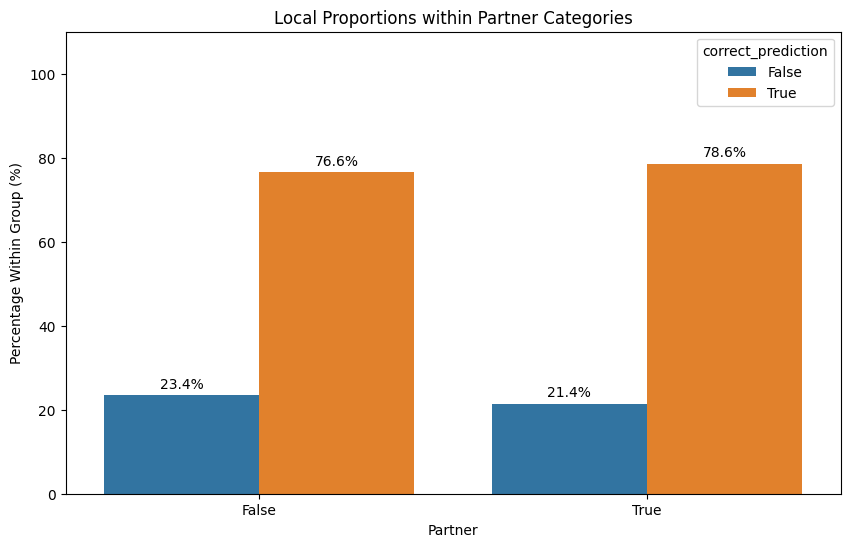

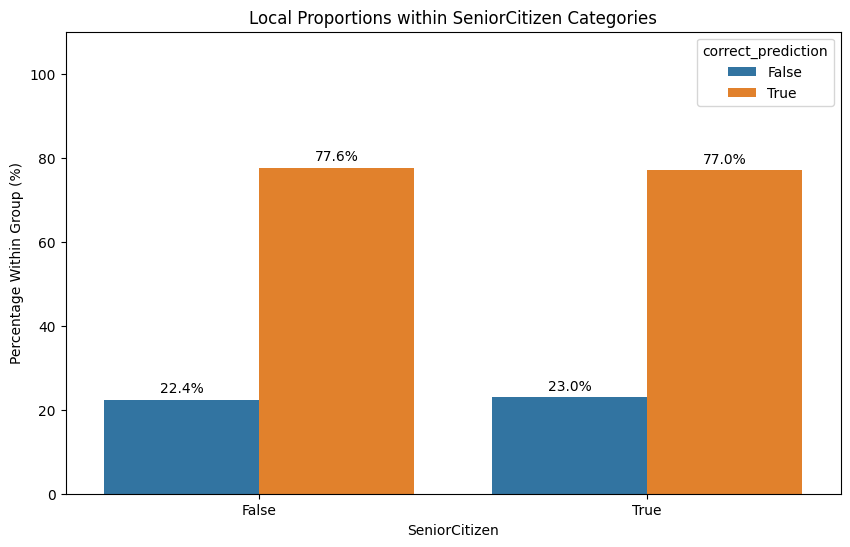

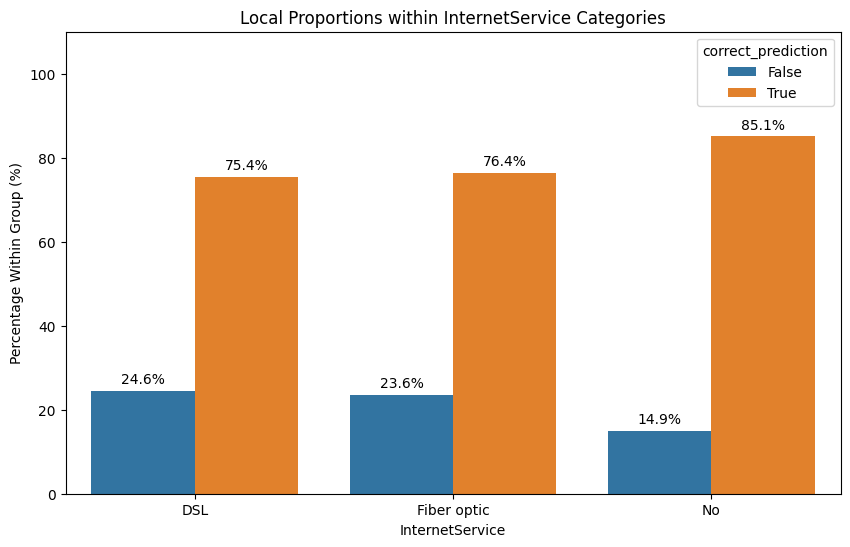

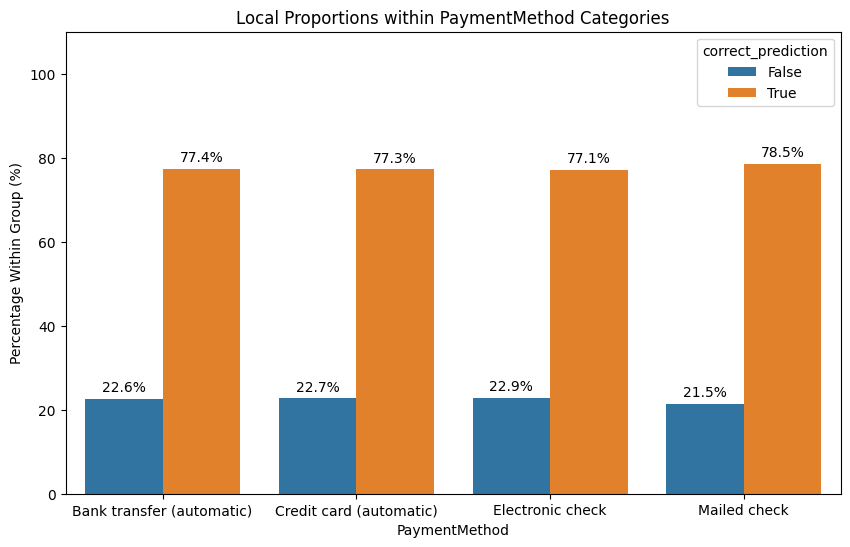

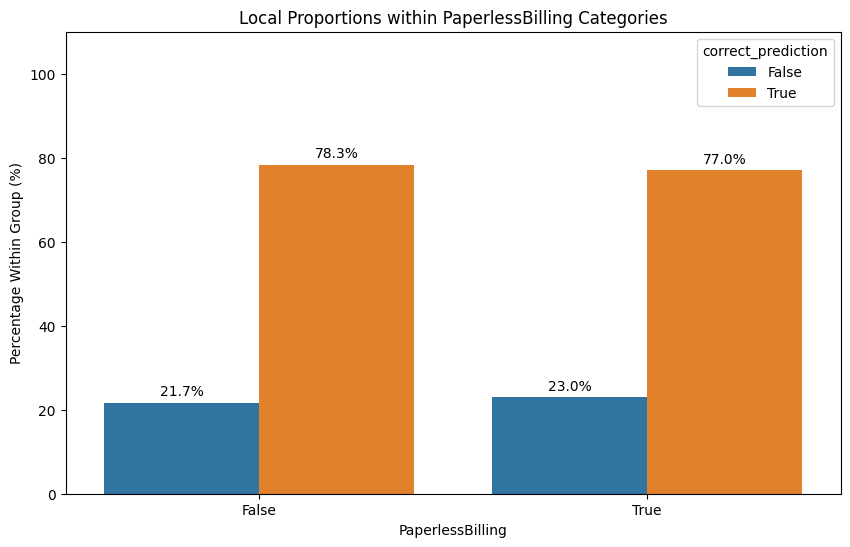

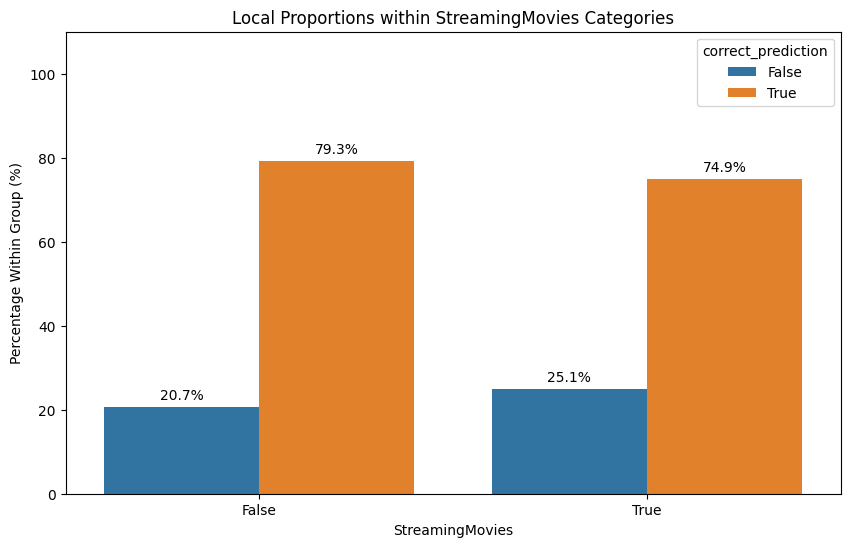

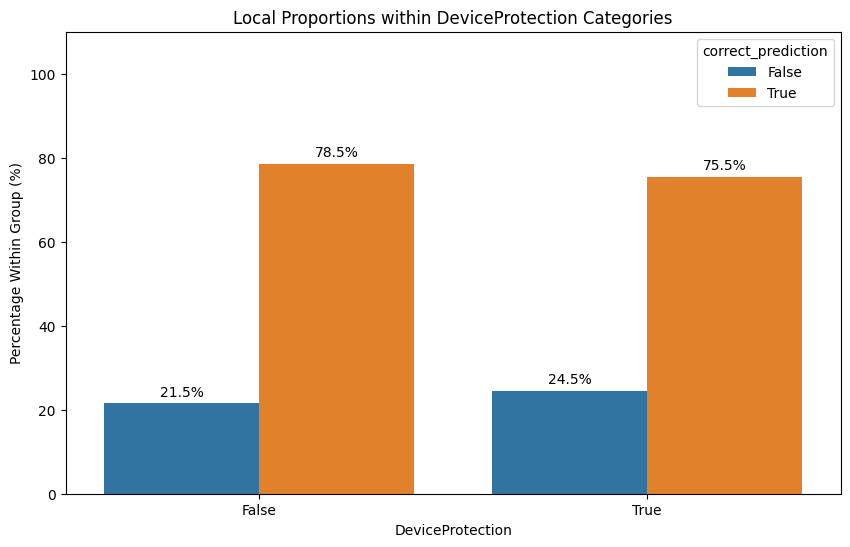

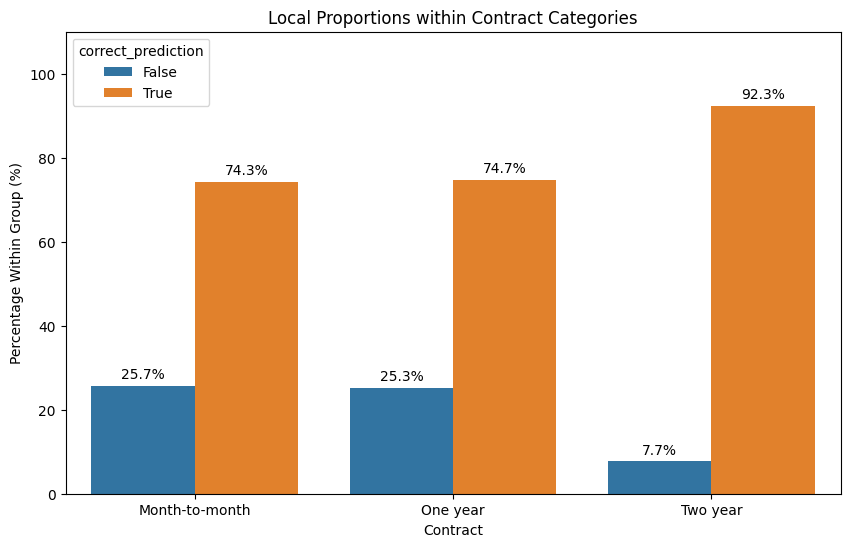

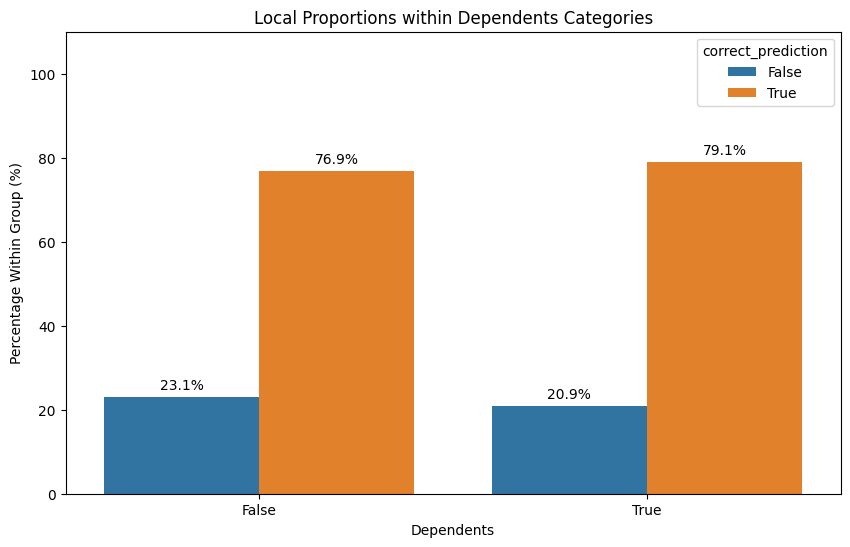

In [53]:
cols = ['Partner', 'SeniorCitizen', 'InternetService', 'PaymentMethod',
       'PaperlessBilling', 'StreamingMovies', 'DeviceProtection', 'Contract',
       'Dependents']
for col in cols:
    plot(col)

"Show the proportion of all categorical columns. They are balanced, except for Contract; if it is a Two-year contract, the correct prediction is 92%."

In [54]:
cols = new.select_dtypes(include=['int64','float64']).columns
print(cols)

Index(['MonthlyCharges', 'tenure'], dtype='str')


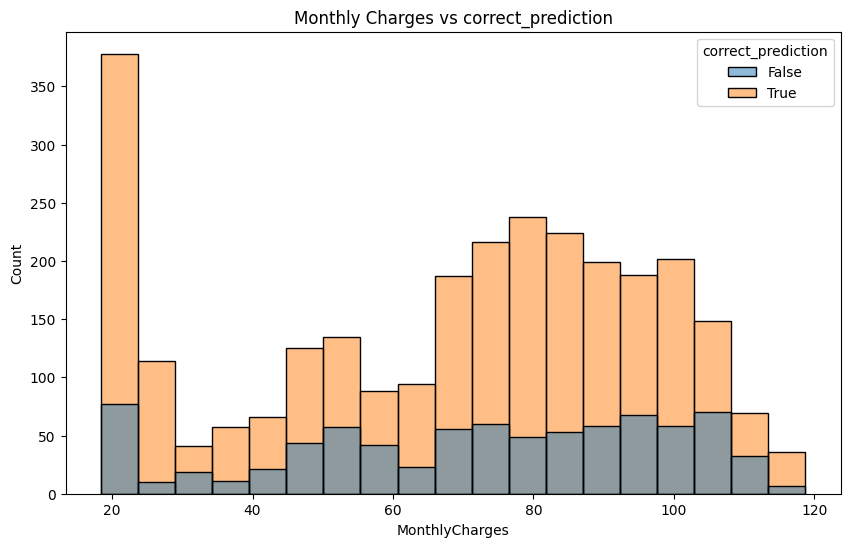

In [57]:
plt.figure(figsize=(10, 6))
sns.histplot(data=new, x='MonthlyCharges', hue='correct_prediction')
plt.title('Monthly Charges vs correct_prediction')
plt.show()

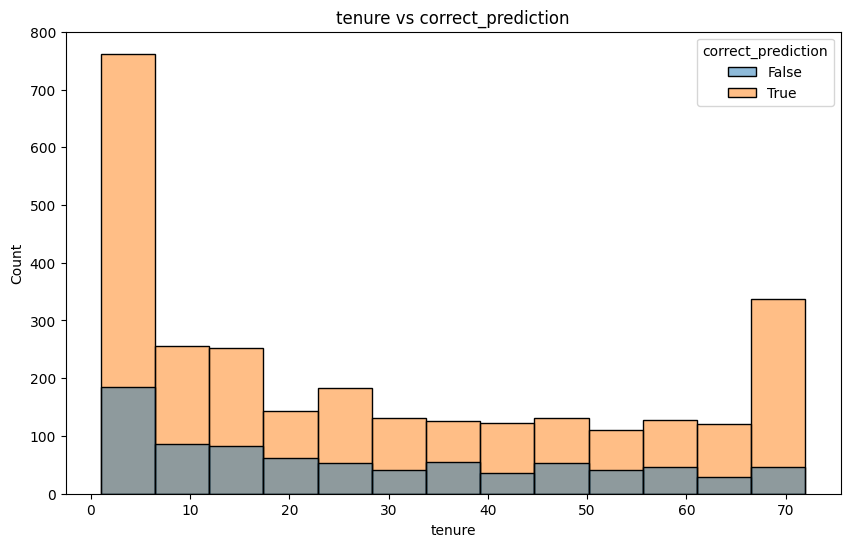

In [58]:
plt.figure(figsize=(10, 6))
sns.histplot(data=new, x='tenure', hue='correct_prediction')
plt.title('tenure vs correct_prediction')
plt.show()

In [59]:
import joblib
joblib.dump(xgb,'model.pkl')
joblib.dump(ct,'ct.pkl')

['ct.pkl']

In [60]:
#saving the model